In [1]:
from src.models.qwen2vl_loader import load_qwen2vl
from src.models.inference import run_inference
from src.data.local_image_loader import load_local_image
from src.config.prompts import FASHION_PROMPTS
from src.utils.paths import FASHION_IMAGES_DIR

model, processor = load_qwen2vl()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

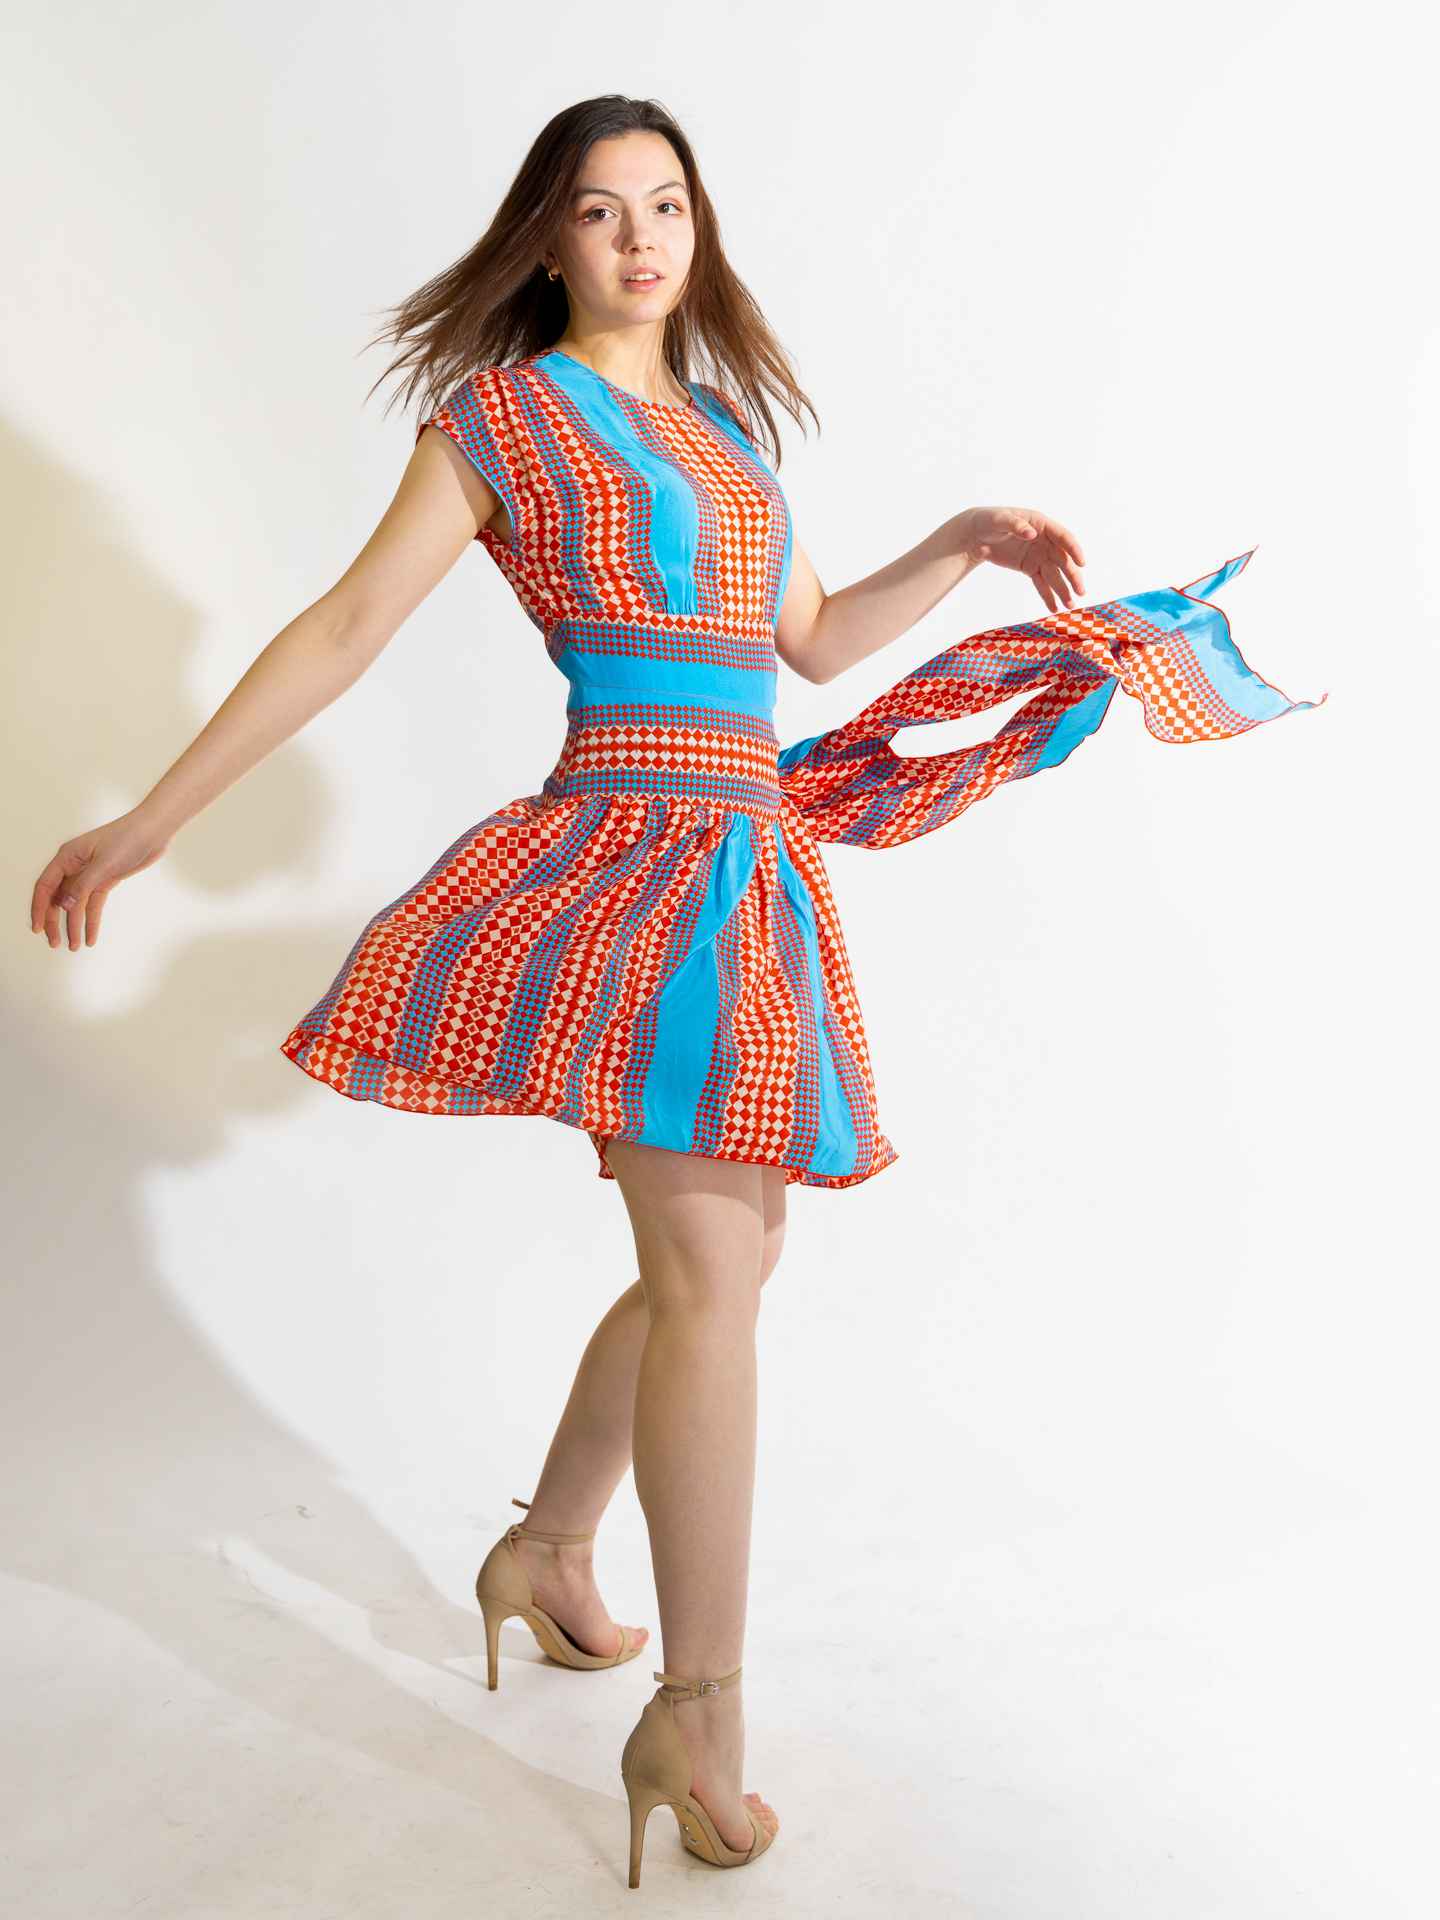

In [2]:
image_path = list(
    FASHION_IMAGES_DIR.glob("*")
)[0]

image = load_local_image(image_path)

image

In [3]:
for prompt_name, prompt_text in FASHION_PROMPTS.items():

    result = run_inference(
        model=model,
        processor=processor,
        image=image,
        prompt=prompt_text,
    )

    print("=" * 60)
    print(prompt_name)
    print("=" * 60)

    print(result["response"])

    print("\nTIME:", result["time_seconds"])
    print("\n")

professional_description
system
You are a helpful assistant.
user
Describe this fashion outfit professionally.
assistant
The fashion outfit depicted is a vibrant and stylish ensemble. The centerpiece is a short-sleeved dress with a fitted bodice and a flared skirt in a striking combination of red and blue geometric patterns. The dress features a high neckline and a fitted waist, creating a dynamic silhouette. The fabric appears to be lightweight and

TIME: 3.87


style_analysis
system
You are a helpful assistant.
user
Analyze the fashion style and aesthetic.
assistant
The fashion style in the image features a vibrant and dynamic aesthetic. The dress is a short-sleeved, knee-length dress with a flared skirt, which adds a playful and casual element to the outfit. The pattern consists of a mix of geometric shapes and colors, primarily in shades of red, blue, and white

TIME: 3.27


luxury_branding
system
You are a helpful assistant.
user
Would this outfit fit luxury fashion branding?
assi

In [4]:
from src.evaluation.basic_metrics import (
    response_length,
    contains_fashion_keywords,
)

result = run_inference(
    model=model,
    processor=processor,
    image=image,
    prompt="Describe this fashion outfit professionally.",
)

response = result["response"]

print(response)

print("\nWord count:")
print(response_length(response))

print("\nFashion keywords:")
print(contains_fashion_keywords(response))

system
You are a helpful assistant.
user
Describe this fashion outfit professionally.
assistant
The fashion outfit depicted is a vibrant and stylish ensemble. The centerpiece is a short-sleeved dress with a fitted bodice and a flared skirt in a striking combination of red and blue geometric patterns. The dress features a high neckline and a fitted waist, creating a dynamic silhouette. The fabric appears to be lightweight and

Word count:
68

Fashion keywords:
['dress', 'fashion', 'outfit']


In [5]:
from src.evaluation.experiment_summary import summarize_results

summary = summarize_results(results)

summary

NameError: name 'results' is not defined